In [33]:
import json
import math
from pathlib import Path
import os
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd


fpath = 'empirical_input'
fruns = 'empirical_runs.json'
INPUT = Path(os.path.join(fpath,fruns))
OUT = Path("empiricial_runs_analysis")
OUT.mkdir(exist_ok=True)
EARTH_RADIUS_KM = 6371.0088

In [2]:
# Some helpers to calculate area of query and other
def bbox_area_km2(bbox):
    """
    [north, south, east, west]
    """
    if not bbox or len(bbox) != 4:
        return np.nan

    north, south, east, west = map(float, bbox)

    return (
        EARTH_RADIUS_KM**2
        * abs(
            math.sin(math.radians(north))
            - math.sin(math.radians(south))
        )
        * math.radians(abs(east - west))
    )


def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def p95(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.95) if len(x) else np.nan


def cv_pct(x):
    """Coefficient of variation [%]."""
    x = pd.to_numeric(x, errors="coerce").dropna()

    if len(x) < 2 or x.mean() == 0:
        return np.nan

    return 100 * x.std(ddof=1) / x.mean()


def summary(df, by, value):
    """
    Extended metrics set.
    """
    return (
        df.groupby(by, dropna=False)[value]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max",
            p95=p95,
            cv_pct=cv_pct,
        )
        .reset_index()
    )


In [3]:
# load data
payload = json.loads(INPUT.read_text(encoding="utf-8"))
runs = payload.get("runs")

In [4]:
# FLATTEN DATA

run_rows = []
dispatch_rows = []
precheck_source_rows = []

for run_id, run in enumerate(runs, start=1):

    request = run.get("request", {})
    precheck = run.get("coverage_precheck", {})
    dispatch = run.get("dispatch", []) or []

    # REQUEST GEOMETRY

    bbox = request.get("bounding_box")

    if bbox and len(bbox) == 4:
        north, south, east, west = bbox
        bbox_width_deg = abs(east - west)
        bbox_height_deg = abs(north - south)
        bbox_area_deg2 = bbox_width_deg * bbox_height_deg
        area_km2 = bbox_area_km2(bbox)
    else:
        north = south = east = west = np.nan
        bbox_width_deg = bbox_height_deg = np.nan
        bbox_area_deg2 = area_km2 = np.nan

    # TIME RANGE

    time_from = pd.to_datetime(
        request.get("time_from"),
        errors="coerce"
    )

    time_to = pd.to_datetime(
        request.get("time_to"),
        errors="coerce"
    )

    if pd.notna(time_from) and pd.notna(time_to):
        # inclusive, np. Jan 1 -- Jan 7 = 7
        duration_days = (time_to - time_from).days + 1
    else:
        duration_days = np.nan

    # SOURCE TIMINGS

    source_times = [
        x["wall_seconds"]
        for x in dispatch
        if x.get("wall_seconds") is not None
    ]

    dispatch_sum = sum(source_times) if source_times else np.nan
    dispatch_max = max(source_times) if source_times else np.nan

    request_wall = run.get("request_wall_seconds", np.nan)

    # PRECHECK
    
    precheck_seconds = precheck.get("precheck_seconds", np.nan)
    candidate_sources = precheck.get("candidate_sources", np.nan)
    dispatched_sources = precheck.get("dispatched_sources", np.nan)
    requests_avoided = precheck.get("requests_avoided", np.nan)

    # OUTPUT

    cells = run.get("returned_cell_count", np.nan)
    rows = run.get("returned_row_count", np.nan)
    non_null = run.get("non_null_value_count", np.nan)

    factors = request.get("factors", []) or []

    # ONE ROW PER COMPLETE REQUEST

    run_rows.append({

        "run_id": run_id,

        "run_kind": run.get("run_kind"),
        "status": run.get("status"),
        "repeat": run.get("repeat"),

        "scenario": request.get("scenario"),
        "country": request.get("country"),

        "dimension": request.get("dimension"),
        "input_value": request.get("input_value"),

        "level": request.get("level"),

        "factor_count_requested": len(factors),
        "factors_requested": " | ".join(factors),

        "time_from": time_from,
        "time_to": time_to,
        "duration_days": duration_days,

        # geometry
        "bbox_width_deg": bbox_width_deg,
        "bbox_height_deg": bbox_height_deg,
        "bbox_area_deg2": bbox_area_deg2,
        "bbox_area_km2": area_km2,

        # total request time
        "request_wall_seconds": request_wall,

        # coverage precheck
        "precheck_seconds": precheck_seconds,
        "precheck_microseconds":
            precheck_seconds * 1e6
            if pd.notna(precheck_seconds)
            else np.nan,

        "candidate_sources": candidate_sources,
        "planned_dispatched_sources": dispatched_sources,
        "recorded_dispatch_count": len(dispatch),
        "requests_avoided": requests_avoided,

        # rejected fraction
        "avoidance_fraction":
            safe_div(requests_avoided, candidate_sources),

        "dispatch_fraction":
            safe_div(dispatched_sources, candidate_sources),

        # precheck cost
        "precheck_overhead_pct":
            100 * safe_div(
                precheck_seconds,
                request_wall
            ),

        # average check cost
        "precheck_us_per_candidate":
            1e6 * safe_div(
                precheck_seconds,
                candidate_sources
            ),

        # data_read success rate
        "dispatch_recording_gap":
            (
                dispatched_sources - len(dispatch)
                if pd.notna(dispatched_sources)
                else np.nan
            ),

        # PARALLELISM / OVERHEAD

        "dispatch_sum_seconds": dispatch_sum,
        "dispatch_max_seconds": dispatch_max,

        # slowest source
        "critical_path_share":
            safe_div(dispatch_max, request_wall),

        # ~= orchestration + merging + transformations itd.
        "orchestration_overhead_seconds":
            (
                request_wall - dispatch_max
                if pd.notna(dispatch_max)
                else np.nan
            ),

        "orchestration_overhead_pct":
            (
                100 * safe_div(
                    request_wall - dispatch_max,
                    request_wall
                )
                if pd.notna(dispatch_max)
                else np.nan
            ),


        "parallelism_factor":
            safe_div(dispatch_sum, dispatch_max),

        # RESULT SIZE

        "returned_cell_count": cells,
        "returned_row_count": rows,
        "returned_column_count":
            run.get("returned_column_count", np.nan),

        "returned_factor_count":
            run.get("returned_factor_count", np.nan),

        "non_null_value_count": non_null,

        "quality_report_count":
            run.get("quality_report_count", np.nan),

        "peak_memory_mb":
            run.get("peak_traced_memory_mb", np.nan),

        # THROUGHPUT


        "cells_per_second":
            safe_div(cells, request_wall),

        "rows_per_second":
            safe_div(rows, request_wall),

        "non_null_values_per_second":
            safe_div(non_null, request_wall),

        "seconds_per_1000_cells":
            1000 * safe_div(request_wall, cells),

        "seconds_per_million_values":
            1_000_000 * safe_div(request_wall, non_null),
    })

    # ONE ROW PER ACTUAL SOURCE REQUEST

    for d in dispatch:

        source = d.get("source")

        dispatch_rows.append({

            "run_id": run_id,

            "scenario": request.get("scenario"),
            "run_kind": run.get("run_kind"),
            "repeat": run.get("repeat"),

            "country": request.get("country"),

            "dimension": request.get("dimension"),
            "input_value": request.get("input_value"),

            "level": request.get("level"),

            "bbox_area_km2": area_km2,
            "bbox_area_deg2": bbox_area_deg2,

            "duration_days": duration_days,
            "factor_count_requested": len(factors),

            "source": source,

            "source_short":
                source.split(".")[-1]
                if source
                else None,

            "source_status": d.get("status"),
            "source_wall_seconds": d.get("wall_seconds"),

            "error": d.get("error"),
        })

    # ONE ROW PER SOURCE CONSIDERED BY PRECHECK

    for source_info in precheck.get("sources", []) or []:

        factor_overlap = source_info.get(
            "factor_overlap", []
        ) or []

        precheck_source_rows.append({

            "run_id": run_id,
            "scenario": request.get("scenario"),
            "repeat": run.get("repeat"),

            "source": source_info.get("source"),

            "source_short":
                source_info
                .get("source", "")
                .split(".")[-1],

            "dispatched":
                bool(source_info.get("dispatched")),

            "factor_overlap_count":
                len(factor_overlap),

            "spatial_overlap":
                bool(source_info.get("spatial_overlap")),

            "temporal_overlap":
                bool(source_info.get("temporal_overlap")),

            "disabled":
                source_info.get("disabled_reason")
                is not None,

            "disabled_reason":
                source_info.get("disabled_reason"),
        })


runs_df = pd.DataFrame(run_rows)
dispatch_df = pd.DataFrame(dispatch_rows)
precheck_sources_df = pd.DataFrame(precheck_source_rows)

In [5]:
runs_df

,run_id,run_kind,status,repeat,scenario,country,dimension,input_value,level,factor_count_requested,...,returned_column_count,returned_factor_count,non_null_value_count,quality_report_count,peak_memory_mb,cells_per_second,rows_per_second,non_null_values_per_second,seconds_per_1000_cells,seconds_per_million_values
0,1,coverage,success,1,germany-meteo-overlap,Germany,None,NaN,10,2,...,74.0,4.0,518.0,2.0,76.024006,0.831821,0.166364,12.310956,1202.181191,8.122846e+04
1,2,coverage,success,1,austria-meteo-overlap,Austria,None,NaN,10,2,...,88.0,4.0,616.0,2.0,7.911102,1.950491,0.333011,29.304939,512.691400,3.412394e+04
2,3,coverage,success,1,ireland-precipitation-overlap,Ireland,None,NaN,10,1,...,25.0,1.0,175.0,1.0,25.810958,0.101704,0.028477,0.711929,9832.446784,1.404635e+06
3,4,coverage,success,1,ireland-groundwater,Ireland,None,NaN,10,1,...,1.0,1.0,90.0,1.0,75.255645,0.146835,13.215164,13.215164,6810.358100,7.567065e+04
4,5,coverage,success,1,germany-land-cover,Germany,None,NaN,10,1,...,532.0,4.0,194712.0,1.0,11.417377,0.137513,0.378419,201.319102,7272.037216,4.967239e+03
5,6,coverage,success,1,germany-soil,Germany,None,NaN,10,1,...,1463.0,11.0,10241.0,1.0,3.224532,2.553722,0.134406,196.636583,391.585323,5.085524e+03
6,7,coverage,no-data,1,no-spatial-coverage,Germany,None,NaN,10,1,...,NaN,NaN,NaN,NaN,1.403826,NaN,NaN,NaN,NaN,NaN
7,8,coverage,no-data,1,no-temporal-coverage,Germany,None,NaN,10,1,...,NaN,NaN,NaN,NaN,0.012425,NaN,NaN,NaN,NaN,NaN
8,9,cross-source,success,1,cross-source-germany-meteo,Germany,None,NaN,10,2,...,74.0,4.0,2294.0,2.0,22.083433,1.314465,1.164240,86.153774,760.765940,1.160715e+04
9,10,cross-source,success,1,cross-source-austria-meteo,Austria,None,NaN,10,2,...,88.0,4.0,2728.0,2.0,3.402300,1.495753,1.130935,99.522308,668.559510,1.004800e+04


In [6]:
dispatch_df

,run_id,scenario,run_kind,repeat,country,dimension,input_value,level,bbox_area_km2,bbox_area_deg2,duration_days,factor_count_requested,source,source_short,source_status,source_wall_seconds,error
0,1,germany-meteo-overlap,coverage,1,Germany,None,NaN,10,7781.036216,1.0,7,2,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,success,15.095390,None
1,1,germany-meteo-overlap,coverage,1,Germany,None,NaN,10,7781.036216,1.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,26.903839,None
2,2,austria-meteo-overlap,coverage,1,Austria,None,NaN,10,8273.257240,1.0,7,2,farmwise_api.adapters.API_readers.geosphere.ge...,geosphere,success,1.721700,None
3,2,austria-meteo-overlap,coverage,1,Austria,None,NaN,10,8273.257240,1.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,19.179901,None
4,3,ireland-precipitation-overlap,coverage,1,Ireland,None,NaN,10,7354.501319,1.0,7,1,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,27.555243,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,58,live-s2-level-8,live-scaling,1,Germany,S2 level,8.0,8,7781.036216,1.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,24.868631,None
123,59,live-bbox-width-2.0,live-scaling,1,Germany,Bounding-box area,4.0,10,31122.959752,4.0,7,2,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,success,27.458865,None
124,59,live-bbox-width-2.0,live-scaling,1,Germany,Bounding-box area,4.0,10,31122.959752,4.0,7,2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,success,27.166795,None
125,60,live-factor-count-1,live-scaling,3,Germany,Factor count,1.0,10,7781.036216,1.0,7,1,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,success,7.597155,None


In [8]:
precheck_sources_df

,run_id,scenario,repeat,source,source_short,dispatched,factor_overlap_count,spatial_overlap,temporal_overlap,disabled,disabled_reason
0,1,germany-meteo-overlap,1,adapters.API_readers.geosphere.geosphere,geosphere,False,2,False,True,False,None
1,1,germany-meteo-overlap,1,adapters.API_readers.wetterdienst.wetterdienst...,wetterdienst_dwd,True,2,True,True,False,None
2,1,germany-meteo-overlap,1,adapters.API_readers.soilgrids.soilgrids_call,soilgrids_call,False,0,True,True,False,None
3,1,germany-meteo-overlap,1,adapters.API_readers.cds.cds_single_levels,cds_single_levels,True,2,True,True,False,None
4,1,germany-meteo-overlap,1,adapters.API_readers.cds.cds_vegetation,cds_vegetation,False,0,True,True,True,The CDS sis-agroproductivity-indicators datase...
...,...,...,...,...,...,...,...,...,...,...,...
907,48,live-bbox-width-2.0,1,adapters.API_readers.irish_meteo.Irish MS_daily,Irish MS_daily,False,1,False,True,False,None
908,48,live-bbox-width-2.0,1,adapters.API_readers.hubeau.hubeau_sw_quality_...,hubeau_sw_quality_read,False,0,True,True,False,None
909,48,live-bbox-width-2.0,1,adapters.API_readers.EuroCropV2.EuroCropV2_read,EuroCropV2_read,False,0,True,True,False,None
910,48,live-bbox-width-2.0,1,adapters.API_readers.IFSGRID.IFSGRID_read,IFSGRID_read,False,0,True,False,False,None


In [7]:
# 1. TIME PER SOURCE
per_source = (
    dispatch_df
    .groupby(["source", "source_short"])
    .agg(
        n=("source_wall_seconds", "count"),

        mean_seconds=("source_wall_seconds", "mean"),
        median_seconds=("source_wall_seconds", "median"),
        std_seconds=("source_wall_seconds", "std"),

        p95_seconds=("source_wall_seconds", p95),

        min_seconds=("source_wall_seconds", "min"),
        max_seconds=("source_wall_seconds", "max"),

        success_rate=(
            "source_status",
            lambda x: (x == "success").mean()
        ),

        timeout_rate=(
            "source_status",
            lambda x: (x == "timeout").mean()
        ),

        failure_rate=(
            "source_status",
            lambda x: (x == "failure").mean()
        ),
    )
    .reset_index()
    .sort_values("mean_seconds", ascending=False)
)


In [8]:
per_source

,source,source_short,n,mean_seconds,median_seconds,std_seconds,p95_seconds,min_seconds,max_seconds,success_rate,timeout_rate,failure_rate
0,farmwise_api.adapters.API_readers.EuroCropV2.E...,EuroCropV2_read,4,405.617888,378.864361,141.126746,569.804553,265.269971,599.472860,0.0,0.0,1.0
1,farmwise_api.adapters.API_readers.IFSGRID.IFSG...,IFSGRID_read,1,366.350394,366.350394,NaN,366.350394,366.350394,366.350394,0.0,0.0,1.0
7,farmwise_api.adapters.API_readers.irish_meteo....,Irish MS_daily,2,207.171873,207.171873,15.668620,217.143322,196.092485,218.251261,0.0,0.0,0.0
8,farmwise_api.adapters.API_readers.soilgrids.so...,soilgrids_call,7,42.676431,44.414915,7.240165,51.140001,34.316516,52.028264,1.0,0.0,0.0
2,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,55,26.182681,23.713264,24.431402,35.265743,15.843918,200.372030,1.0,0.0,0.0
9,farmwise_api.adapters.API_readers.wetterdienst...,wetterdienst_dwd,50,8.459691,7.444818,5.414025,21.895301,1.651134,27.899360,1.0,0.0,0.0
4,farmwise_api.adapters.API_readers.epa_ireland....,epa_gw,1,6.797291,6.797291,NaN,6.797291,6.797291,6.797291,1.0,0.0,0.0
5,farmwise_api.adapters.API_readers.geosphere.ge...,geosphere,2,2.059600,2.059600,0.477863,2.363710,1.721700,2.397500,1.0,0.0,0.0
3,farmwise_api.adapters.API_readers.corine.corin...,corine_read,4,1.295388,1.294546,0.009101,1.305511,1.285506,1.306951,1.0,0.0,0.0
6,farmwise_api.adapters.API_readers.imgw.imgw_ap...,imgw_api_synop_daily,1,0.209770,0.209770,NaN,0.209770,0.209770,0.209770,0.0,0.0,1.0


In [9]:
# 2. per query times
per_query = summary(
    runs_df,
    [
        "scenario",
        "dimension",
        "input_value",
        "level",
        "country",
    ],
    "request_wall_seconds"
)
per_query

,scenario,dimension,input_value,level,country,n,mean,median,std,min,max,p95,cv_pct
0,austria-meteo-overlap,NaN,NaN,10,Austria,1,21.020347,21.020347,NaN,21.020347,21.020347,21.020347,NaN
1,cross-source-austria-meteo,NaN,NaN,10,Austria,1,27.410940,27.410940,NaN,27.410940,27.410940,27.410940,NaN
2,cross-source-germany-meteo,NaN,NaN,10,Germany,1,26.626808,26.626808,NaN,26.626808,26.626808,26.626808,NaN
3,cross-source-ireland-precipitation,NaN,NaN,10,Ireland,1,221.437961,221.437961,NaN,221.437961,221.437961,221.437961,NaN
4,cross-source-poland-meteo,NaN,NaN,10,Poland,1,28.754719,28.754719,NaN,28.754719,28.754719,28.754719,NaN
5,germany-land-cover,NaN,NaN,10,Germany,1,967.180950,967.180950,NaN,967.180950,967.180950,967.180950,NaN
6,germany-meteo-overlap,NaN,NaN,10,Germany,1,42.076342,42.076342,NaN,42.076342,42.076342,42.076342,NaN
7,germany-soil,NaN,NaN,10,Germany,1,52.080848,52.080848,NaN,52.080848,52.080848,52.080848,NaN
8,ireland-groundwater,NaN,NaN,10,Ireland,1,6.810358,6.810358,NaN,6.810358,6.810358,6.810358,NaN
9,ireland-precipitation-overlap,NaN,NaN,10,Ireland,1,245.811170,245.811170,NaN,245.811170,245.811170,245.811170,NaN


In [10]:
# 3. Level scaling test
s2 = runs_df[
    runs_df["dimension"] == "S2 level"
].copy()

per_level = summary(
    s2,
    ["level"],
    "request_wall_seconds"
)

level_extra = (
    s2.groupby("level")
    .agg(
        cells_mean=("returned_cell_count", "mean"),
        memory_mean_mb=("peak_memory_mb", "mean"),
        values_mean = ('non_null_value_count','mean'),
        values_per_second_mean=(
            "non_null_values_per_second",
            "mean"
        )
    )
    .reset_index()
)

per_level = per_level.merge(
    level_extra,
    on="level"
)
per_level

,level,n,mean,median,std,min,max,p95,cv_pct,cells_mean,memory_mean_mb,values_mean,values_per_second_mean
0,6,3,33.229094,31.432349,8.681158,25.586901,42.668034,41.544465,26.125171,4.0,21.883248,56.0,1.760894
1,8,3,30.886395,32.354026,3.208128,27.206967,33.098192,33.023775,10.386865,13.0,21.882003,182.0,5.937840
2,10,3,28.728774,26.990144,3.518689,26.417829,32.778348,32.199527,12.247962,35.0,21.852310,490.0,17.217249
3,12,3,30.854446,31.467352,1.431715,29.218307,31.877681,31.836648,4.640222,37.0,21.853396,518.0,16.813244


In [11]:
level_extra

,level,cells_mean,memory_mean_mb,values_mean,values_per_second_mean
0,6,4.0,21.883248,56.0,1.760894
1,8,13.0,21.882003,182.0,5.937840
2,10,35.0,21.852310,490.0,17.217249
3,12,37.0,21.853396,518.0,16.813244


In [12]:
# 4. BOUNDING BOX / QUERY AREA SCALING

area_runs = runs_df[
    runs_df["dimension"] == "Bounding-box area"
].copy()

per_area = summary(
    area_runs,
    [
        "input_value",
        "bbox_area_deg2",
        "bbox_area_km2",
    ],
    "request_wall_seconds"
)

area_extra = (
    area_runs
    .groupby(
        [
            "input_value",
            "bbox_area_deg2",
            "bbox_area_km2"
        ]
    )
    .agg(
        cells_mean=("returned_cell_count", "mean"),

        memory_mean_mb=(
            "peak_memory_mb",
            "mean"
        ),
                values_mean = ('non_null_value_count','mean'),
        cells_per_second_mean=(
            "cells_per_second",
            "mean"
        ),
    )
    .reset_index()
)

per_area = per_area.merge(
    area_extra,
    on=[
        "input_value",
        "bbox_area_deg2",
        "bbox_area_km2",
    ]
)

area_extra

,input_value,bbox_area_deg2,bbox_area_km2,cells_mean,memory_mean_mb,values_mean,cells_per_second_mean
0,0.0625,0.0625,486.320550,2.0,9.734226,28.0,0.090056
1,0.2500,0.2500,1945.277572,10.0,11.759540,140.0,0.390247
2,1.0000,1.0000,7781.036216,35.0,21.853647,490.0,1.222480
3,4.0000,4.0000,31122.959752,126.0,24.608086,1764.0,2.291115


In [13]:
per_area

,input_value,bbox_area_deg2,bbox_area_km2,n,mean,median,std,min,max,p95,cv_pct,cells_mean,memory_mean_mb,values_mean,cells_per_second_mean
0,0.0625,0.0625,486.320550,3,22.564102,20.556065,3.626469,20.385807,26.750434,26.130997,16.071851,2.0,9.734226,28.0,0.090056
1,0.2500,0.2500,1945.277572,3,26.728019,28.765064,6.275999,19.686541,31.732452,31.435714,23.480972,10.0,11.759540,140.0,0.390247
2,1.0000,1.0000,7781.036216,3,28.873546,29.024334,3.226222,25.574574,32.021731,31.721991,11.173626,35.0,21.853647,490.0,1.222480
3,4.0000,4.0000,31122.959752,3,55.180220,55.847130,3.877703,51.012316,58.681215,58.397806,7.027342,126.0,24.608086,1764.0,2.291115


In [14]:
# 5. NUMBER OF FACTORS SCALING


factor_runs = runs_df[
    runs_df["dimension"] == "Factor count"
].copy()

per_factor_count = summary(
    factor_runs,
    ["factor_count_requested"],
    "request_wall_seconds"
)

factor_extra = (
    factor_runs
    .groupby("factor_count_requested")
    .agg(
        returned_factors_mean=(
            "returned_factor_count",
            "mean"
        ),

        columns_mean=(
            "returned_column_count",
            "mean"
        ),

        memory_mean_mb=(
            "peak_memory_mb",
            "mean"
        ),

        values_per_second_mean=(
            "non_null_values_per_second",
            "mean"
        ),
    )
    .reset_index()
)

per_factor_count = per_factor_count.merge(
    factor_extra,
    on="factor_count_requested"
)

factor_extra

,factor_count_requested,returned_factors_mean,columns_mean,memory_mean_mb,values_per_second_mean
0,1,1.0,35.0,21.881758,5.593292
1,2,2.0,70.0,21.853632,17.502924
2,3,13.0,1533.0,21.885756,128.768023
3,4,17.0,2065.0,21.885129,487.870499


In [15]:
per_factor_count

,factor_count_requested,n,mean,median,std,min,max,p95,cv_pct,returned_factors_mean,columns_mean,memory_mean_mb,values_per_second_mean
0,1,3,90.254371,31.668365,101.923474,31.149667,207.945080,190.317409,112.929128,1.0,35.0,21.881758,5.593292
1,2,3,28.421358,29.328987,4.152932,23.889677,32.045412,31.773769,14.612011,2.0,70.0,21.853632,17.502924
2,3,3,83.826001,84.310726,7.805094,75.789842,91.377436,90.670765,9.311065,13.0,1533.0,21.885756,128.768023
3,4,3,427.951996,445.274715,69.145380,351.792295,486.788978,482.637552,16.157275,17.0,2065.0,21.885129,487.870499


In [16]:
# 6. REQUEST DURATION SCALING

duration_runs = runs_df[
    runs_df["dimension"] == "Requested days"
].copy()

per_duration = summary(
    duration_runs,
    ["duration_days"],
    "request_wall_seconds"
)

duration_extra = (
    duration_runs
    .groupby("duration_days")
    .agg(
        rows_mean=("returned_row_count", "mean"),
        cells_mean=("returned_cell_count", "mean"),
        columns_mean=("returned_column_count", "mean"),
        memory_mean_mb=("peak_memory_mb", "mean"),
        values_mean=("non_null_value_count", "mean"),
        values_per_second_mean=(
            "non_null_values_per_second",
            "mean"
        ),
    )
    .reset_index()
)

per_duration = per_duration.merge(
    duration_extra,
    on="duration_days"
)

per_duration

,duration_days,n,mean,median,std,min,max,p95,cv_pct,rows_mean,cells_mean,columns_mean,memory_mean_mb,values_mean,values_per_second_mean
0,1,3,24.388802,23.643138,1.428527,23.487397,26.035870,25.796597,5.857308,1.0,35.0,70.0,21.853435,70.0,2.876537
1,7,3,32.384170,27.839408,9.970878,25.495368,43.817733,42.219900,30.789357,7.0,35.0,70.0,21.915874,490.0,16.000938
2,30,3,36.275773,33.014085,10.939305,27.338295,48.474940,46.928854,30.155952,30.0,35.0,70.0,21.851494,2100.0,61.248630
3,90,3,35.413220,36.224882,3.062482,32.026667,37.988109,37.811787,8.647849,90.0,35.0,70.0,21.881855,6300.0,178.822015


In [17]:
# 6. SOURCE TIME PER LEVEL
source_by_level = summary(
    dispatch_df,
    ["source_short", "level"],
    "source_wall_seconds"
)

source_by_level

,source_short,level,n,mean,median,std,min,max,p95,cv_pct
0,EuroCropV2_read,10,4,405.617888,378.864361,141.126746,265.269971,599.472860,569.804553,34.793028
1,IFSGRID_read,10,1,366.350394,366.350394,NaN,366.350394,366.350394,366.350394,NaN
2,Irish MS_daily,10,2,207.171873,207.171873,15.668620,196.092485,218.251261,217.143322,7.563102
3,cds_single_levels,6,3,25.662086,23.952961,8.632761,18.011725,35.021572,33.914711,33.640138
4,cds_single_levels,8,3,23.323658,24.868631,3.304484,19.529680,25.572662,25.502258,14.167948
5,cds_single_levels,10,46,26.641387,23.708559,26.657026,15.843918,200.372030,34.299319,100.058702
6,cds_single_levels,12,3,22.528815,23.654244,2.170825,20.026374,23.905826,23.880668,9.635770
7,corine_read,10,4,1.295388,1.294546,0.009101,1.285506,1.306951,1.305511,0.702600
8,epa_gw,10,1,6.797291,6.797291,NaN,6.797291,6.797291,6.797291,NaN
9,geosphere,10,2,2.059600,2.059600,0.477863,1.721700,2.397500,2.363710,23.201750


In [19]:
# 7. SOURCE TIME PER QUERY AREA

source_by_area = summary(
    dispatch_df[
        dispatch_df["dimension"] == "Bounding-box area"
    ],
    [
        "source_short",
        "input_value",
        "bbox_area_km2",
    ],
    "source_wall_seconds"
)
source_by_area

,source_short,input_value,bbox_area_km2,n,mean,median,std,min,max,p95,cv_pct
0,cds_single_levels,0.0625,486.320550,3,20.771726,18.820708,3.499655,18.682480,24.811992,24.212863,16.848165
1,cds_single_levels,0.2500,1945.277572,3,23.735640,25.741304,6.311929,16.664577,28.801038,28.495065,26.592621
2,cds_single_levels,1.0000,7781.036216,3,21.026618,21.158911,2.987284,17.975385,23.945557,23.666893,14.207155
3,cds_single_levels,4.0000,31122.959752,3,26.156539,27.166795,4.133105,21.611969,29.690853,29.438447,15.801420
4,wetterdienst_dwd,0.0625,486.320550,3,1.739355,1.689108,0.121411,1.651134,1.877824,1.858952,6.980242
5,wetterdienst_dwd,0.2500,1945.277572,3,2.740460,2.740229,0.036364,2.704212,2.776939,2.773268,1.326943
6,wetterdienst_dwd,1.0000,7781.036216,3,7.428108,7.418626,0.167884,7.265167,7.600532,7.582342,2.260115
7,wetterdienst_dwd,4.0000,31122.959752,3,27.701811,27.747208,0.223729,27.458865,27.899360,27.884145,0.807633


In [20]:
# 8. SOURCE TIME PER FACTOR COUNT

source_by_factor_count = summary(
    dispatch_df[
        dispatch_df["dimension"] == "Factor count"
    ],
    [
        "source_short",
        "factor_count_requested",
    ],
    "source_wall_seconds"
)
source_by_factor_count

,source_short,factor_count_requested,n,mean,median,std,min,max,p95,cv_pct
0,EuroCropV2_read,4,3,340.999564,356.044578,69.440413,265.269971,401.684144,397.120187,20.363784
1,cds_single_levels,1,3,82.596382,23.713264,101.996702,23.703854,200.372030,182.706153,123.488099
2,cds_single_levels,2,3,19.412157,17.585943,4.471267,16.143047,24.507481,23.815327,23.033335
3,cds_single_levels,3,3,19.843666,19.306813,3.780770,16.360018,23.864167,23.408432,19.052782
4,cds_single_levels,4,3,22.977028,23.784958,1.550828,21.189046,23.957081,23.939868,6.749471
5,corine_read,4,3,1.291533,1.291741,0.005925,1.285506,1.297351,1.296790,0.458780
6,soilgrids_call,3,3,46.886887,47.178358,2.339892,44.414915,49.067388,48.878485,4.990503
7,soilgrids_call,4,3,35.348697,35.515515,0.959709,34.316516,36.214062,36.144207,2.714978
8,wetterdienst_dwd,1,3,7.333521,7.278791,0.240976,7.124618,7.597155,7.565319,3.285950
9,wetterdienst_dwd,2,3,8.591503,7.381852,2.294973,7.154404,11.238254,10.852614,26.712125


In [21]:
# 9. COVERAGE PRECHECK

precheck_summary = pd.DataFrame([{

    "mean_us":
        runs_df["precheck_microseconds"].mean(),

    "median_us":
        runs_df["precheck_microseconds"].median(),

    "p95_us":
        p95(runs_df["precheck_microseconds"]),

    "max_us":
        runs_df["precheck_microseconds"].max(),

    "mean_overhead_pct":
        runs_df["precheck_overhead_pct"].mean(),

    "mean_candidates":
        runs_df["candidate_sources"].mean(),

    "mean_dispatched":
        runs_df["planned_dispatched_sources"].mean(),

    "mean_requests_avoided":
        runs_df["requests_avoided"].mean(),

    "mean_avoidance_fraction":
        runs_df["avoidance_fraction"].mean(),

    "mean_us_per_candidate":
        runs_df["precheck_us_per_candidate"].mean(),
}])
precheck_summary

,mean_us,median_us,p95_us,max_us,mean_overhead_pct,mean_candidates,mean_dispatched,mean_requests_avoided,mean_avoidance_fraction,mean_us_per_candidate
0,220.165,173.550001,392.245,982.199999,0.113145,19.0,2.133333,16.866667,0.887719,11.587632


In [22]:
# 10. WHY SOURCES ARE REJECTED

precheck_by_source = (
    precheck_sources_df
    .groupby(["source", "source_short"])
    .agg(
        considered=("run_id", "count"),

        dispatched=(
            "dispatched",
            "sum"
        ),

        disabled=(
            "disabled",
            "sum"
        ),

        no_factor_overlap=(
            "factor_overlap_count",
            lambda x: (x == 0).sum()
        ),

        no_spatial_overlap=(
            "spatial_overlap",
            lambda x: (~x).sum()
        ),

        no_temporal_overlap=(
            "temporal_overlap",
            lambda x: (~x).sum()
        ),
    )
    .reset_index()
)

precheck_by_source["dispatch_rate"] = (
    precheck_by_source["dispatched"]
    / precheck_by_source["considered"]
)
precheck_by_source

,source,source_short,considered,dispatched,disabled,no_factor_overlap,no_spatial_overlap,no_temporal_overlap,dispatch_rate
0,farmwise_api.adapters.API_readers.EuroCropV2.E...,EuroCropV2_read,60,4,0,56,0,1,0.066667
1,farmwise_api.adapters.API_readers.IFSGRID.IFSG...,IFSGRID_read,60,1,0,56,0,56,0.016667
2,farmwise_api.adapters.API_readers.UA_sw_qualit...,ukrainian_surface_water,60,0,0,60,60,0,0.000000
3,farmwise_api.adapters.API_readers.cds.cds_sing...,cds_single_levels,60,55,0,5,0,0,0.916667
4,farmwise_api.adapters.API_readers.cds.cds_vege...,cds_vegetation,60,0,60,59,0,4,0.000000
5,farmwise_api.adapters.API_readers.corine.corin...,corine_read,60,4,0,56,0,0,0.066667
6,farmwise_api.adapters.API_readers.eea.eea_read,eea_read,60,0,0,60,0,0,0.000000
7,farmwise_api.adapters.API_readers.epa_ireland....,epa_gw,60,1,0,58,57,0,0.016667
8,farmwise_api.adapters.API_readers.geosphere.ge...,geosphere,60,2,0,5,58,0,0.033333
9,farmwise_api.adapters.API_readers.gios.gios_sc...,gios_scraper,60,0,0,53,59,1,0.000000


In [23]:
# 11. REPEATABILITY / NOISE

live = runs_df[
    runs_df["run_kind"] == "live-scaling"
]

repeat_stability = (
    live.groupby(
        [
            "scenario",
            "dimension",
            "input_value",
        ]
    )
    .agg(
        repeats=("repeat", "nunique"),

        request_mean_seconds=(
            "request_wall_seconds",
            "mean"
        ),

        request_std_seconds=(
            "request_wall_seconds",
            "std"
        ),

        request_cv_pct=(
            "request_wall_seconds",
            cv_pct
        ),

        request_min_seconds=(
            "request_wall_seconds",
            "min"
        ),

        request_max_seconds=(
            "request_wall_seconds",
            "max"
        ),

        memory_mean_mb=(
            "peak_memory_mb",
            "mean"
        ),

        memory_cv_pct=(
            "peak_memory_mb",
            cv_pct
        ),
    )
    .reset_index()
    .sort_values(
        "request_cv_pct",
        ascending=False
    )
)
repeat_stability

,scenario,dimension,input_value,repeats,request_mean_seconds,request_std_seconds,request_cv_pct,request_min_seconds,request_max_seconds,memory_mean_mb,memory_cv_pct
8,live-factor-count-1,Factor count,1.0000,3,90.254371,101.923474,112.929128,31.149667,207.945080,21.881758,0.221003
6,live-duration-days-7,Requested days,7.0000,3,32.384170,9.970878,30.789357,25.495368,43.817733,21.915874,0.252018
5,live-duration-days-30,Requested days,30.0000,3,36.275773,10.939305,30.155952,27.338295,48.474940,21.851494,0.010390
14,live-s2-level-6,S2 level,6.0000,3,33.229094,8.681158,26.125171,25.586901,42.668034,21.883248,0.225598
1,live-bbox-width-0.5,Bounding-box area,0.2500,3,26.728019,6.275999,23.480972,19.686541,31.732452,11.759540,0.429134
11,live-factor-count-4,Factor count,4.0000,3,427.951996,69.145380,16.157275,351.792295,486.788978,21.885129,0.254660
0,live-bbox-width-0.25,Bounding-box area,0.0625,3,22.564102,3.626469,16.071851,20.385807,26.750434,9.734226,0.003380
9,live-factor-count-2,Factor count,2.0000,3,28.421358,4.152932,14.612011,23.889677,32.045412,21.853632,0.005978
12,live-s2-level-10,S2 level,10.0000,3,28.728774,3.518689,12.247962,26.417829,32.778348,21.852310,0.002247
2,live-bbox-width-1.0,Bounding-box area,1.0000,3,28.873546,3.226222,11.173626,25.574574,32.021731,21.853647,0.005516


# Cross-source

In [24]:
fpath = 'empirical_input'
fcorss = 'cross_source_observations_live.csv'
INPUT = Path(os.path.join(fpath,fcorss))
OUT = Path("observation_overview")
OUT.mkdir(exist_ok=True)
KEY = [
    "scenario",
    "timestamp",
    "cell",
    "variable",
]
df = pd.read_csv(INPUT)
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    errors="coerce"
)
df["value"] = pd.to_numeric(
    df["value"],
    errors="coerce"
)

In [25]:
KEY = [
    "scenario",
    "timestamp",
    "cell",
    "variable",
]

n_sources = (
    df.groupby(KEY)["source"]
      .nunique()
      .rename("n_sources")
      .reset_index()
)

duplicated_keys = n_sources[
    n_sources["n_sources"] > 1
]

print("All unique observation keys:", len(n_sources))
print("Keys covered by >1 source:", len(duplicated_keys))
print(
    "Share with cross-source overlap:",
    f"{100 * len(duplicated_keys) / len(n_sources):.3f}%"
)

print("\nNumber of sources per observation:")
print(
    n_sources["n_sources"]
    .value_counts()
    .sort_index()
)

All unique observation keys: 12741
Keys covered by >1 source: 310
Share with cross-source overlap: 2.433%

Number of sources per observation:
1    12431
2      310
Name: n_sources, dtype: int64


In [26]:
overlap = df.merge(
    duplicated_keys[KEY],
    on=KEY,
    how="inner"
)

In [27]:
from itertools import combinations
pair_rows = []

for key_values, same in overlap.groupby(KEY):

    scenario, timestamp, cell, variable = key_values

    # protection against accidental duplicates within one source
    same = (
        same.groupby("source", as_index=False)
            .agg(value=("value", "mean"))
    )

    for (_, a), (_, b) in combinations(
        same.iterrows(),
        2,
    ):

        value_a = a["value"]
        value_b = b["value"]

        if pd.isna(value_a) or pd.isna(value_b):
            continue

        # alphabetical order → stable pair names
        if a["source"] <= b["source"]:
            source_a = a["source"]
            source_b = b["source"]
            va = value_a
            vb = value_b
        else:
            source_a = b["source"]
            source_b = a["source"]
            va = value_b
            vb = value_a

        diff = va - vb

        pair_rows.append({
            "scenario": scenario,
            "timestamp": timestamp,
            "cell": cell,
            "variable": variable,

            "source_a": source_a,
            "source_b": source_b,

            "source_pair":
                f"{source_a} – {source_b}",

            "value_a": va,
            "value_b": vb,

            # signed difference
            "difference": diff,

            # absolute disagreement
            "absolute_difference": abs(diff),

            # midpoint of the two values
            "pair_mean":
                (va + vb) / 2,
        })


pairs = pd.DataFrame(pair_rows)

print("\nPairwise comparisons:", len(pairs))
print("\nPairs:")
print(
    pairs["source_pair"]
    .value_counts()
)


Pairwise comparisons: 310

Pairs:
ERA5 – GeoSphere    186
DWD – ERA5          124
Name: source_pair, dtype: int64


In [28]:
def rmse(x):
    return np.sqrt(np.mean(x ** 2))


summary = (
    pairs
    .groupby(
        [
            "scenario",
            "variable",
            "source_pair",
        ]
    )
    .agg(
        n=("difference", "size"),

        # systematic difference: A - B
        mean_bias=("difference", "mean"),
        median_bias=("difference", "median"),

        # magnitude of disagreement
        mae=("absolute_difference", "mean"),
        median_absolute_difference=(
            "absolute_difference",
            "median"
        ),

        p90_absolute_difference=(
            "absolute_difference",
            lambda x: x.quantile(0.90)
        ),

        p95_absolute_difference=(
            "absolute_difference",
            lambda x: x.quantile(0.95)
        ),

        max_absolute_difference=(
            "absolute_difference",
            "max"
        ),

        rmse=(
            "difference",
            rmse
        ),
    )
    .reset_index()
)

summary

,scenario,variable,source_pair,n,mean_bias,median_bias,mae,median_absolute_difference,p90_absolute_difference,p95_absolute_difference,max_absolute_difference,rmse
0,cross-source-austria-meteo,precipitation,ERA5 – GeoSphere,93,4.739511,2.190807,4.868734,2.626245,13.477775,17.057206,31.409554,7.887344
1,cross-source-austria-meteo,temperature,ERA5 – GeoSphere,93,-1.087835,-0.921484,1.207805,0.921484,2.643322,2.976360,3.845184,1.527141
2,cross-source-germany-meteo,precipitation,DWD – ERA5,62,-9.613490,-7.415147,9.662558,7.415147,22.952585,32.238848,37.405222,13.972886
3,cross-source-germany-meteo,temperature,DWD – ERA5,62,-0.319564,-0.054672,1.293927,1.285696,1.976597,2.225399,2.465314,1.421629


In [29]:
# Add correlation separately
correlations = []

for keys, same in pairs.groupby(
    [
        "scenario",
        "variable",
        "source_pair",
    ]
):
    scenario, variable, source_pair = keys

    if (
        len(same) >= 2
        and same["value_a"].std() > 0
        and same["value_b"].std() > 0
    ):
        r = same[
            ["value_a", "value_b"]
        ].corr().iloc[0, 1]

    else:
        r = np.nan

    correlations.append({
        "scenario": scenario,
        "variable": variable,
        "source_pair": source_pair,
        "pearson_r": r,
    })


correlations = pd.DataFrame(correlations)
correlations

,scenario,variable,source_pair,pearson_r
0,cross-source-austria-meteo,precipitation,ERA5 – GeoSphere,0.661560
1,cross-source-austria-meteo,temperature,ERA5 – GeoSphere,0.939515
2,cross-source-germany-meteo,precipitation,DWD – ERA5,0.842494
3,cross-source-germany-meteo,temperature,DWD – ERA5,0.881180


In [30]:
summary = summary.merge(
    correlations,
    on=[
        "scenario",
        "variable",
        "source_pair",
    ],
    how="left"
)
summary

,scenario,variable,source_pair,n,mean_bias,median_bias,mae,median_absolute_difference,p90_absolute_difference,p95_absolute_difference,max_absolute_difference,rmse,pearson_r
0,cross-source-austria-meteo,precipitation,ERA5 – GeoSphere,93,4.739511,2.190807,4.868734,2.626245,13.477775,17.057206,31.409554,7.887344,0.661560
1,cross-source-austria-meteo,temperature,ERA5 – GeoSphere,93,-1.087835,-0.921484,1.207805,0.921484,2.643322,2.976360,3.845184,1.527141,0.939515
2,cross-source-germany-meteo,precipitation,DWD – ERA5,62,-9.613490,-7.415147,9.662558,7.415147,22.952585,32.238848,37.405222,13.972886,0.842494
3,cross-source-germany-meteo,temperature,DWD – ERA5,62,-0.319564,-0.054672,1.293927,1.285696,1.976597,2.225399,2.465314,1.421629,0.881180


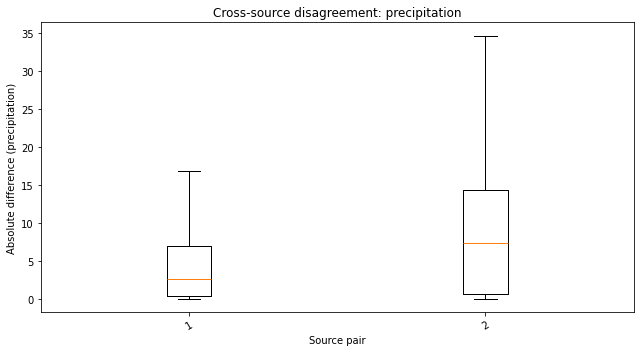

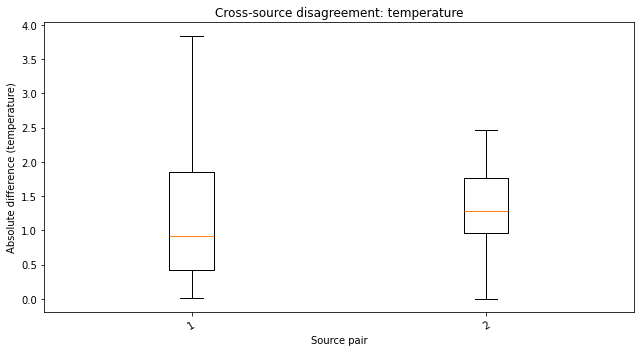

In [34]:
variables = pairs["variable"].unique()

for variable in variables:

    sub = pairs[
        pairs["variable"] == variable
    ].copy()

    pairs_order = (
        sub.groupby("source_pair")["absolute_difference"]
           .median()
           .sort_values()
           .index
    )

    data = [
        sub.loc[
            sub["source_pair"] == pair,
            "absolute_difference"
        ].dropna()
        for pair in pairs_order
    ]
    fig, ax = plt.subplots(
        figsize=(9, 5)
    )

    ax.boxplot(
        data,
        showfliers=False
    )
    ax.set_ylabel(
        f"Absolute difference ({variable})"
    )

    ax.set_xlabel(
        "Source pair"
    )

    ax.set_title(
        f"Cross-source disagreement: {variable}"
    )

    ax.tick_params(
        axis="x",
        rotation=30
    )

    fig.tight_layout()

    fig.savefig(
        f"cross_source_difference_{variable}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

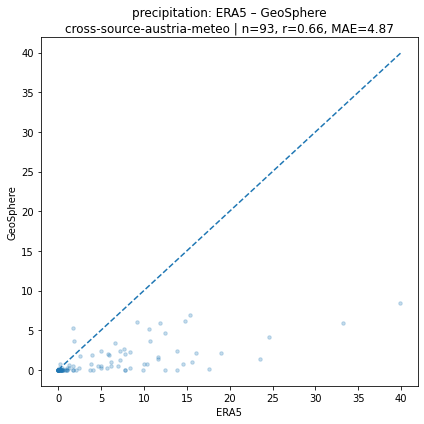

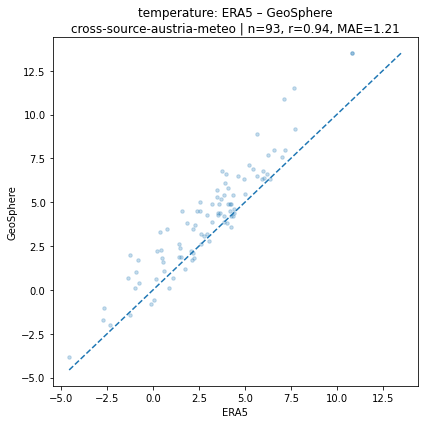

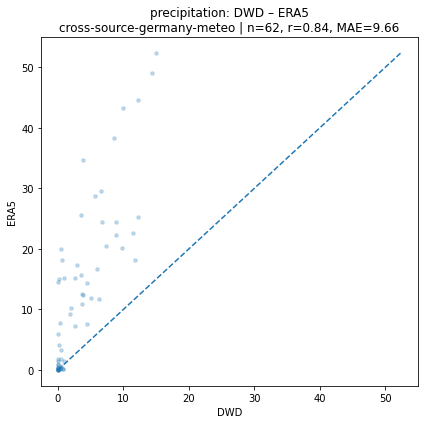

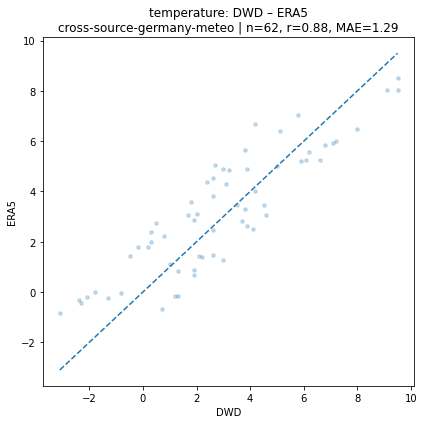

In [35]:
for (
    scenario,
    variable,
    source_pair
), sub in pairs.groupby(
    [
        "scenario",
        "variable",
        "source_pair",
    ]
):

    if len(sub) < 10:
        continue

    fig, ax = plt.subplots(
        figsize=(6, 6)
    )

    ax.scatter(
        sub["value_a"],
        sub["value_b"],
        alpha=0.25,
        s=12
    )

    minimum = min(
        sub["value_a"].min(),
        sub["value_b"].min()
    )

    maximum = max(
        sub["value_a"].max(),
        sub["value_b"].max()
    )

    # perfect agreement line
    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel(
        sub["source_a"].iloc[0]
    )

    ax.set_ylabel(
        sub["source_b"].iloc[0]
    )

    r = sub[
        ["value_a", "value_b"]
    ].corr().iloc[0, 1]

    mae = sub[
        "absolute_difference"
    ].mean()

    ax.set_title(
        f"{variable}: {source_pair}\n"
        f"{scenario} | n={len(sub):,}, "
        f"r={r:.2f}, MAE={mae:.2f}"
    )

    fig.tight_layout()

    plt.show()

In [36]:
from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

QUALITY_DIR = INPUT.parent / payload.get(
    "quality_report_dir",
    "quality",
)
OUT_DIR = Path("quality_summary")

OUT_DIR.mkdir(exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def load_quality_report(path: Path) -> dict:
    """
    Supports:
      - JSON quality reports
      - one-row CSV quality reports

    The attached example is JSON.
    """

    # First try JSON, regardless of extension
    try:
        with path.open("r", encoding="utf-8") as f:
            obj = json.load(f)

        if isinstance(obj, dict):
            return obj

    except (json.JSONDecodeError, UnicodeDecodeError):
        pass


def to_datetime(value):
    return pd.to_datetime(
        value,
        errors="coerce",
    )


def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def p05(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.05) if len(x) else np.nan


def p95(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.95) if len(x) else np.nan


def cv_pct(x):
    x = pd.to_numeric(x, errors="coerce").dropna()

    if len(x) < 2 or x.mean() == 0:
        return np.nan

    return (
        100
        * x.std(ddof=1)
        / abs(x.mean())
    )


def summarise_group(group):
    """
    Summarise a set of quality reports.
    """

    result = {
        # number of reports
        "n_reports": len(group),

        # ----------------------------------------------------
        # S2 completeness
        # ----------------------------------------------------

        "S2_completeness_mean":
            group["S2_completeness"].mean(),

        "S2_completeness_median":
            group["S2_completeness"].median(),

        "S2_completeness_std":
            group["S2_completeness"].std(),

        "S2_completeness_p05":
            p05(group["S2_completeness"]),

        "S2_completeness_p95":
            p95(group["S2_completeness"]),

        "S2_completeness_min":
            group["S2_completeness"].min(),

        "S2_completeness_max":
            group["S2_completeness"].max(),

        # weighted by expected number of S2 cells
        "S2_completeness_weighted":
            safe_div(
                group["returned_s2_cells"].sum(),
                group["expected_s2_cells"].sum(),
            ),

        "expected_s2_cells_total":
            group["expected_s2_cells"].sum(),

        "returned_s2_cells_total":
            group["returned_s2_cells"].sum(),

        "missing_s2_cells_total":
            group["missing_s2_cells"].sum(),

        # ----------------------------------------------------
        # TEMPORAL COMPLETENESS
        # ----------------------------------------------------

        "missing_days_mean":
            group["missing_days"].mean(),

        "missing_days_median":
            group["missing_days"].median(),

        "missing_days_p95":
            p95(group["missing_days"]),

        "missing_days_max":
            group["missing_days"].max(),

        "reports_with_missing_days":
            (group["missing_days"] > 0).sum(),

        "reports_with_missing_days_pct":
            100 * (group["missing_days"] > 0).mean(),

        # independently derived from expected/returned
        # date boundaries
        "start_delay_days_mean":
            group["start_delay_days"].mean(),

        "end_cutshort_days_mean":
            group["end_cutshort_days"].mean(),

        "temporal_span_completeness_mean":
            group["temporal_span_completeness"].mean(),

        "temporal_span_completeness_min":
            group["temporal_span_completeness"].min(),

        # ----------------------------------------------------
        # MISSING VALUES
        # ----------------------------------------------------

        "total_missing_values_mean":
            group["total_missing_values"].mean(),

        "total_missing_values_median":
            group["total_missing_values"].median(),

        "total_missing_values_p95":
            p95(group["total_missing_values"]),

        "total_missing_values_max":
            group["total_missing_values"].max(),

        "reports_with_missing_values":
            (group["total_missing_values"] > 0).sum(),

        "reports_with_missing_values_pct":
            100
            * (group["total_missing_values"] > 0).mean(),

        "factor_missing_values_mean":
            group["factor_missing_values"].mean(),

        # ----------------------------------------------------
        # ERROR / IMPLAUSIBLE VALUES
        # ----------------------------------------------------

        "error_values_mean":
            group["error_values"].mean(),

        "error_values_median":
            group["error_values"].median(),

        "error_values_p95":
            p95(group["error_values"]),

        "error_values_max":
            group["error_values"].max(),

        "reports_with_error_values":
            (group["error_values"] > 0).sum(),

        "reports_with_error_values_pct":
            100
            * (group["error_values"] > 0).mean(),

        # ----------------------------------------------------
        # FACTOR COMPLETENESS
        # ----------------------------------------------------

        "factor_completeness_mean":
            group["factors_returned_completeness"].mean(),

        "factor_completeness_median":
            group["factors_returned_completeness"].median(),

        "factor_completeness_min":
            group["factors_returned_completeness"].min(),

        "factor_completeness_p05":
            p05(group["factors_returned_completeness"]),

        "expected_factors_total":
            group["expected_factor_count"].sum(),

        "returned_factors_total":
            group["returned_factor_count"].sum(),

        # overall weighted factor completeness
        "factor_completeness_weighted":
            safe_div(
                group["returned_factor_count"].sum(),
                group["expected_factor_count"].sum(),
            ),

        "reports_with_incomplete_factors":
            (
                group["factors_returned_completeness"] < 1
            ).sum(),

        "reports_with_incomplete_factors_pct":
            100 * (
                group["factors_returned_completeness"] < 1
            ).mean(),
    }

    return pd.Series(result)


# ============================================================
# READ ALL FILES
# ============================================================

report_rows = []
factor_rows = []

files = [
    p
    for p in QUALITY_DIR.iterdir()
    if p.is_file()
]

print(
    f"Found {len(files):,} quality report files."
)


for path in files:

    try:
        report = load_quality_report(path)

    except Exception as e:
        print(
            f"SKIPPING {path.name}: {e}"
        )
        continue

    # --------------------------------------------------------
    # BASIC VALUES
    # --------------------------------------------------------

    source = report.get("source")

    # fallback to filename if source field is absent
    if not source:
        filename = path.stem

        if "_" in filename:
            source = filename.split(
                "_",
                maxsplit=1,
            )[1]

    level = pd.to_numeric(
        report.get("S2_level"),
        errors="coerce",
    )

    expected_s2 = pd.to_numeric(
        report.get("expected_s2_cells"),
        errors="coerce",
    )

    returned_s2 = pd.to_numeric(
        report.get("returned_s2_cells"),
        errors="coerce",
    )

    # --------------------------------------------------------
    # DATES
    # --------------------------------------------------------

    expected_start = to_datetime(
        report.get("expected_start")
    )

    expected_end = to_datetime(
        report.get("expected_end")
    )

    returned_start = to_datetime(
        report.get("returned_start")
    )

    returned_end = to_datetime(
        report.get("returned_end")
    )

    if (
        pd.notna(expected_start)
        and pd.notna(expected_end)
    ):
        expected_days = (
            expected_end - expected_start
        ).days + 1
    else:
        expected_days = np.nan

    if (
        pd.notna(returned_start)
        and pd.notna(returned_end)
    ):
        returned_span_days = (
            returned_end - returned_start
        ).days + 1
    else:
        returned_span_days = np.nan

    # delay at beginning
    if (
        pd.notna(expected_start)
        and pd.notna(returned_start)
    ):
        start_delay_days = max(
            0,
            (returned_start - expected_start).days,
        )
    else:
        start_delay_days = np.nan

    # missing end
    if (
        pd.notna(expected_end)
        and pd.notna(returned_end)
    ):
        end_cutshort_days = max(
            0,
            (expected_end - returned_end).days,
        )
    else:
        end_cutshort_days = np.nan

    temporal_span_completeness = (
        safe_div(
            returned_span_days,
            expected_days,
        )
    )

    # cap at 1 in case source gives a slightly larger range
    if pd.notna(temporal_span_completeness):
        temporal_span_completeness = min(
            1.0,
            temporal_span_completeness,
        )

    # --------------------------------------------------------
    # FACTORS
    # --------------------------------------------------------

    factors_expected = (
        report.get("factors_expected", [])
        or []
    )

    factors_returned = (
        report.get("factors_returned", [])
        or []
    )

    expected_factor_count = len(
        factors_expected
    )

    returned_factor_count = len(
        factors_returned
    )

    # --------------------------------------------------------
    # REPORT-LEVEL ROW
    # --------------------------------------------------------

    report_rows.append({
        "filename": path.name,

        "request_id":
            report.get("request_id"),

        "created_at":
            to_datetime(
                report.get("created_at")
            ),

        "source":
            source,

        "api_name":
            report.get("api_name"),

        "S2_level":
            level,

        # S2
        "S2_completeness":
            pd.to_numeric(
                report.get("S2_completeness"),
                errors="coerce",
            ),

        "expected_s2_cells":
            expected_s2,

        "returned_s2_cells":
            returned_s2,

        "missing_s2_cells":
            (
                expected_s2 - returned_s2
                if (
                    pd.notna(expected_s2)
                    and pd.notna(returned_s2)
                )
                else np.nan
            ),

        # dates
        "expected_start":
            expected_start,

        "expected_end":
            expected_end,

        "returned_start":
            returned_start,

        "returned_end":
            returned_end,

        "expected_days":
            expected_days,

        "returned_span_days":
            returned_span_days,

        "start_delay_days":
            start_delay_days,

        "end_cutshort_days":
            end_cutshort_days,

        "temporal_span_completeness":
            temporal_span_completeness,

        # values supplied directly by report
        "missing_days":
            pd.to_numeric(
                report.get("missing_days"),
                errors="coerce",
            ),

        "data_delay":
            pd.to_numeric(
                report.get("data_delay"),
                errors="coerce",
            ),

        "data_cutshort":
            pd.to_numeric(
                report.get("data_cutshort"),
                errors="coerce",
            ),

        "total_missing_values":
            pd.to_numeric(
                report.get(
                    "total_missing_values"
                ),
                errors="coerce",
            ),

        "factor_missing_values":
            pd.to_numeric(
                report.get(
                    "factor_missing_values"
                ),
                errors="coerce",
            ),

        "error_values":
            pd.to_numeric(
                report.get("error_values"),
                errors="coerce",
            ),

        # factors
        "expected_factor_count":
            expected_factor_count,

        "returned_factor_count":
            returned_factor_count,

        "factors_expected":
            " | ".join(
                map(str, factors_expected)
            ),

        "factors_returned":
            " | ".join(
                map(str, factors_returned)
            ),

        "factors_returned_completeness":
            pd.to_numeric(
                report.get(
                    "factors_returned_completeness"
                ),
                errors="coerce",
            ),
    })

    # ========================================================
    # FACTOR-LEVEL QUALITY
    # ========================================================

    missing_rates = (
        report.get(
            "factor_missing_value_rates",
            {}
        )
        or {}
    )

    implausible_rates = (
        report.get(
            "implausible_value_rates",
            {}
        )
        or {}
    )

    factor_names = set(
        missing_rates
    ) | set(
        implausible_rates
    )

    for factor in factor_names:

        factor_rows.append({
            "filename":
                path.name,

            "request_id":
                report.get("request_id"),

            "source":
                source,

            "S2_level":
                level,

            "factor":
                factor,

            "missing_value_rate":
                pd.to_numeric(
                    missing_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),

            "implausible_value_rate":
                pd.to_numeric(
                    implausible_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),
        })


reports_df = pd.DataFrame(report_rows)
factors_df = pd.DataFrame(factor_rows)


# ============================================================
# ADD GENERAL ISSUE FLAG
# ============================================================

reports_df["has_quality_issue"] = (
    (reports_df["missing_days"] > 0)
    | (reports_df["total_missing_values"] > 0)
    | (reports_df["error_values"] > 0)
    | (
        reports_df[
            "factors_returned_completeness"
        ] < 1
    )
    | (
        reports_df[
            "S2_completeness"
        ] < 1
    )
)


# ============================================================
# SUMMARY PER SOURCE
# ============================================================

by_source = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
)


# ============================================================
# SUMMARY PER S2 LEVEL
# ============================================================

by_level = (
    reports_df
    .groupby(
        "S2_level",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values("S2_level")
)


# ============================================================
# SUMMARY PER SOURCE × S2 LEVEL
# ============================================================

by_source_level = (
    reports_df
    .groupby(
        [
            "source",
            "S2_level",
        ],
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values(
        [
            "source",
            "S2_level",
        ]
    )
)


# ============================================================
# FACTOR-LEVEL SUMMARY
# ============================================================

if not factors_df.empty:

    by_factor = (
        factors_df
        .groupby(
            [
                "source",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            missing_rate_max=(
                "missing_value_rate",
                "max",
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),

            implausible_rate_max=(
                "implausible_value_rate",
                "max",
            ),
        )
        .reset_index()
    )

    by_factor_level = (
        factors_df
        .groupby(
            [
                "source",
                "S2_level",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),
        )
        .reset_index()
    )

else:

    by_factor = pd.DataFrame()
    by_factor_level = pd.DataFrame()


# ============================================================
# ISSUE SUMMARY
#
# Useful for presentation:
# "what proportion of requests exhibit each problem?"
# ============================================================

issue_summary = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .agg(
        n_reports=(
            "request_id",
            "size",
        ),

        any_quality_issue=(
            "has_quality_issue",
            "sum",
        ),

        incomplete_S2=(
            "S2_completeness",
            lambda x: (x < 1).sum(),
        ),

        missing_days=(
            "missing_days",
            lambda x: (x > 0).sum(),
        ),

        missing_values=(
            "total_missing_values",
            lambda x: (x > 0).sum(),
        ),

        error_values=(
            "error_values",
            lambda x: (x > 0).sum(),
        ),

        incomplete_factors=(
            "factors_returned_completeness",
            lambda x: (x < 1).sum(),
        ),
    )
    .reset_index()
)

for col in [
    "any_quality_issue",
    "incomplete_S2",
    "missing_days",
    "missing_values",
    "error_values",
    "incomplete_factors",
]:

    issue_summary[f"{col}_pct"] = (
        100
        * issue_summary[col]
        / issue_summary["n_reports"]
    )

Found 504 quality report files.


In [37]:
by_source

,source,n_reports,S2_completeness_mean,S2_completeness_median,S2_completeness_std,S2_completeness_p05,S2_completeness_p95,S2_completeness_min,S2_completeness_max,S2_completeness_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,expected_factors_total,returned_factors_total,factor_completeness_weighted,reports_with_incomplete_factors,reports_with_incomplete_factors_pct
0,adapters.API_readers.cds.cds_single_levels,127.0,0.320235,0.183824,3.269288e-01,0.013463,1.000000,0.013463,1.000000,0.145345,...,0.000000,1.0,1.0,1.0,1.0,235.0,235.0,1.0,0.0,0.0
1,adapters.API_readers.corine.corine_read,13.0,0.980747,0.977941,5.331563e-03,0.977941,0.990099,0.977941,0.990099,0.985729,...,0.000000,1.0,1.0,1.0,1.0,13.0,52.0,4.0,0.0,0.0
2,adapters.API_readers.epa_ireland.epa_gw,5.0,0.003141,0.001910,2.752537e-03,0.001910,0.006834,0.001910,0.008065,0.001916,...,80.000000,1.0,1.0,1.0,1.0,5.0,5.0,1.0,0.0,0.0
3,adapters.API_readers.geosphere.geosphere,10.0,0.215300,0.129252,1.657799e-01,0.067683,0.405941,0.067683,0.405941,0.081194,...,0.000000,1.0,1.0,1.0,1.0,16.0,16.0,1.0,0.0,0.0
4,adapters.API_readers.soilgrids.soilgrids_call,19.0,0.977941,0.977941,1.140646e-16,0.977941,0.977941,0.977941,0.977941,0.977941,...,0.000000,1.0,1.0,1.0,1.0,19.0,209.0,11.0,0.0,0.0
5,adapters.API_readers.wetterdienst.wetterdienst...,117.0,0.152561,0.088235,1.644591e-01,0.006462,0.500000,0.006462,0.596958,0.055501,...,97.435897,1.0,1.0,1.0,1.0,219.0,219.0,1.0,0.0,0.0
6,farmwise_api.adapters.API_readers.cds.cds_sing...,102.0,0.231614,0.183824,2.195595e-01,0.071429,0.928571,0.013463,1.000000,0.115943,...,0.000000,1.0,1.0,1.0,1.0,191.0,191.0,1.0,0.0,0.0
7,farmwise_api.adapters.API_readers.corine.corin...,8.0,0.977941,0.977941,1.186878e-16,0.977941,0.977941,0.977941,0.977941,0.977941,...,0.000000,1.0,1.0,1.0,1.0,8.0,32.0,4.0,0.0,0.0
8,farmwise_api.adapters.API_readers.epa_ireland....,4.0,0.008065,0.008065,0.000000e+00,0.008065,0.008065,0.008065,0.008065,0.008065,...,0.000000,1.0,1.0,1.0,1.0,4.0,4.0,1.0,0.0,0.0
9,farmwise_api.adapters.API_readers.geosphere.ge...,10.0,0.129252,0.129252,2.925695e-17,0.129252,0.129252,0.129252,0.129252,0.129252,...,0.000000,1.0,1.0,1.0,1.0,20.0,20.0,1.0,0.0,0.0


In [38]:
by_level

,S2_level,n_reports,S2_completeness_mean,S2_completeness_median,S2_completeness_std,S2_completeness_p05,S2_completeness_p95,S2_completeness_min,S2_completeness_max,S2_completeness_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,expected_factors_total,returned_factors_total,factor_completeness_weighted,reports_with_incomplete_factors,reports_with_incomplete_factors_pct
0,6,33.0,0.735078,0.916667,0.260804,0.363636,1.000000,0.363636,1.000000,0.790036,...,36.363636,1.0,1.0,1.0,1.0,59.0,59.0,1.00000,0.0,0.0
1,7,3.0,0.990099,0.990099,0.000000,0.990099,0.990099,0.990099,0.990099,0.990099,...,0.000000,1.0,1.0,1.0,1.0,3.0,12.0,4.00000,0.0,0.0
2,8,35.0,0.701588,0.596958,0.229299,0.405941,0.940860,0.405941,0.940860,0.804878,...,28.571429,1.0,1.0,1.0,1.0,70.0,70.0,1.00000,0.0,0.0
3,10,401.0,0.236548,0.164300,0.284581,0.053323,0.977941,0.008065,0.977941,0.190948,...,20.698254,1.0,1.0,1.0,1.0,699.0,1073.0,1.53505,0.0,0.0
4,12,32.0,0.008956,0.006462,0.004288,0.001910,0.013463,0.001910,0.013463,0.004414,...,40.625000,1.0,1.0,1.0,1.0,60.0,60.0,1.00000,0.0,0.0


In [39]:
issue_summary

,source,n_reports,any_quality_issue,incomplete_S2,missing_days,missing_values,error_values,incomplete_factors,any_quality_issue_pct,incomplete_S2_pct,missing_days_pct,missing_values_pct,error_values_pct,incomplete_factors_pct
0,adapters.API_readers.cds.cds_single_levels,127,118,118,0,0,0,0,92.913386,92.913386,0.000000,0.000000,0.000000,0.0
1,adapters.API_readers.corine.corine_read,13,13,13,0,0,0,0,100.000000,100.000000,0.000000,0.000000,0.000000,0.0
2,adapters.API_readers.epa_ireland.epa_gw,5,5,5,5,5,4,0,100.000000,100.000000,100.000000,100.000000,80.000000,0.0
3,adapters.API_readers.geosphere.geosphere,10,10,10,0,0,0,0,100.000000,100.000000,0.000000,0.000000,0.000000,0.0
4,adapters.API_readers.soilgrids.soilgrids_call,19,19,19,0,0,0,0,100.000000,100.000000,0.000000,0.000000,0.000000,0.0
5,adapters.API_readers.wetterdienst.wetterdienst...,117,117,117,4,4,114,0,100.000000,100.000000,3.418803,3.418803,97.435897,0.0
6,farmwise_api.adapters.API_readers.cds.cds_sing...,102,98,98,0,0,0,0,96.078431,96.078431,0.000000,0.000000,0.000000,0.0
7,farmwise_api.adapters.API_readers.corine.corin...,8,8,8,0,0,0,0,100.000000,100.000000,0.000000,0.000000,0.000000,0.0
8,farmwise_api.adapters.API_readers.epa_ireland....,4,4,4,4,4,0,0,100.000000,100.000000,100.000000,100.000000,0.000000,0.0
9,farmwise_api.adapters.API_readers.geosphere.ge...,10,10,10,0,0,0,0,100.000000,100.000000,0.000000,0.000000,0.000000,0.0
